# Final Project: Rental Price Prediction
---
**Objective:** Build a predictive model to estimate monthly rental prices (`rent_eur_month`) based on property features.

## 1. Environment Setup & Data Loading


In [2]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")


# ── Reproducibility ──────────────────────────────────────────────────────────
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

# ── Data Loading ─────────────────────────────────────────────────────────────

df_train = pd.read_csv("track_a_rental_pricing_train.csv")
df_test = pd.read_csv("track_a_rental_pricing_test.csv")

X_train = df_train.drop(columns=["rent_eur_month"])
Y_train = df_train["rent_eur_month"]

X_test = df_test.drop(columns=["rent_eur_month"])
Y_test = df_test["rent_eur_month"]

## 2. Exploratory Data Analysis
### 2.1. Feature Analysis
**We observe** that our dataset contains 12 distinct features of mixed data types (binary flags, bounded integers, and continuous). Processing these features the same way might lead us to mathematical distortions. Thus, we partition our features into three distinct groups.

*Note: While `distance_supermarket_m` is technically represented as an integer, we will treat is as a continuous variable due to its high range*



In [8]:
CONTINUOUS = ['surface_m2', 'building_age_years', 'distance_metro_km',
              'district_prestige_score', 'construction_quality_score', 'distance_supermarket_m']

DISCRETE   = ['num_rooms', 'floor_number', 'energy_rating',
              'num_photos']

BINARY     = ['has_elevator', 'has_parking']

ALL_FEATURES = CONTINUOUS + DISCRETE + BINARY

#### 2.2. Heatmap of Continuous Features

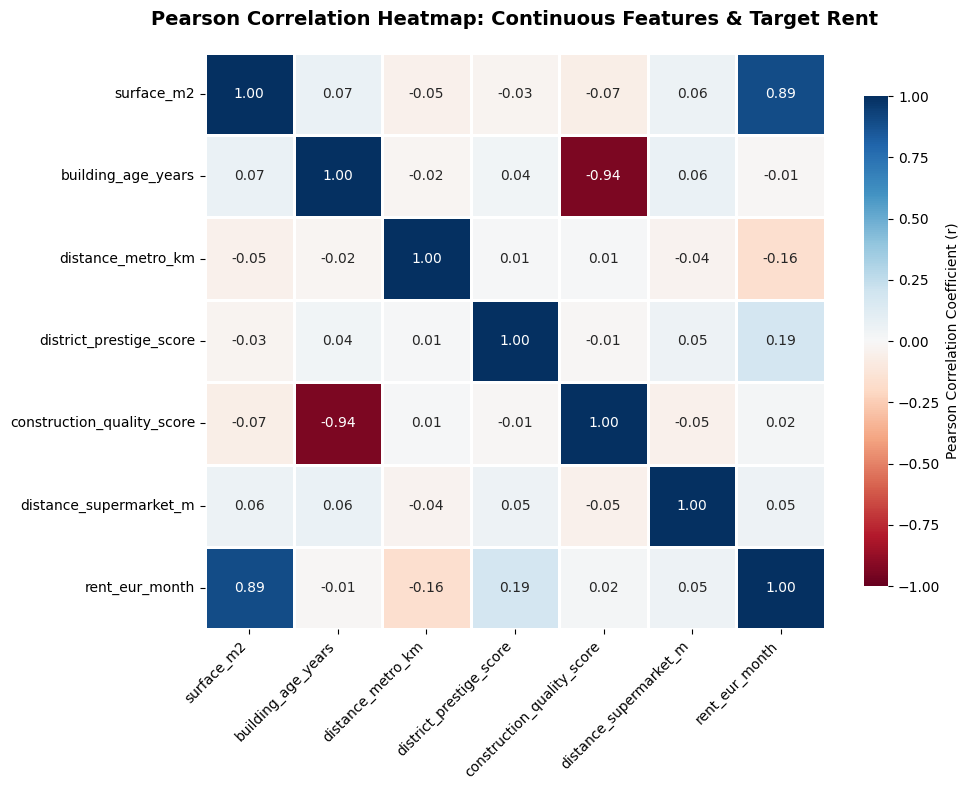

In [4]:
df_continuous = df_train[CONTINUOUS + ["rent_eur_month"]] # extracting continuous features + rent

continuous_corr = df_continuous.corr(method="pearson") # calculating the correlation matrix

plt.figure(figsize=(10, 8))

sns.heatmap(
    continuous_corr,
    annot=True,  
    cmap="RdBu",  
    fmt=".2f",  
    vmin=-1,
    vmax=1,  
    linewidths=0.75,  
    cbar_kws={"shrink": 0.85, "label": "Pearson Correlation Coefficient (r)"},
)

plt.title(
    "Pearson Correlation Heatmap: Continuous Features & Target Rent",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation

`surface_m2` exhibits the strongest positive linear correlation with rent (**r ≈ 0.89**), confirming it as the dominant predictor.

Moreover, we observe a significant negavite correlation between `construction_quality_score` and `building_age_years` (**r ≈ −0.94**), which is consistent with the physical reality that older buildings have lower quality scores than the newer ones. We need to keep this in mind as such severe multicollinearity can affect our predictions.

All remaining continuous features hold moderate to little correlation with rental prices.

### 2.3. Correlation of Discrete Features

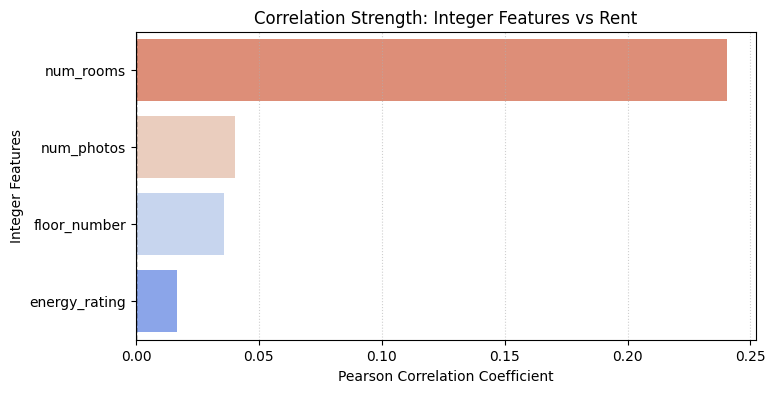

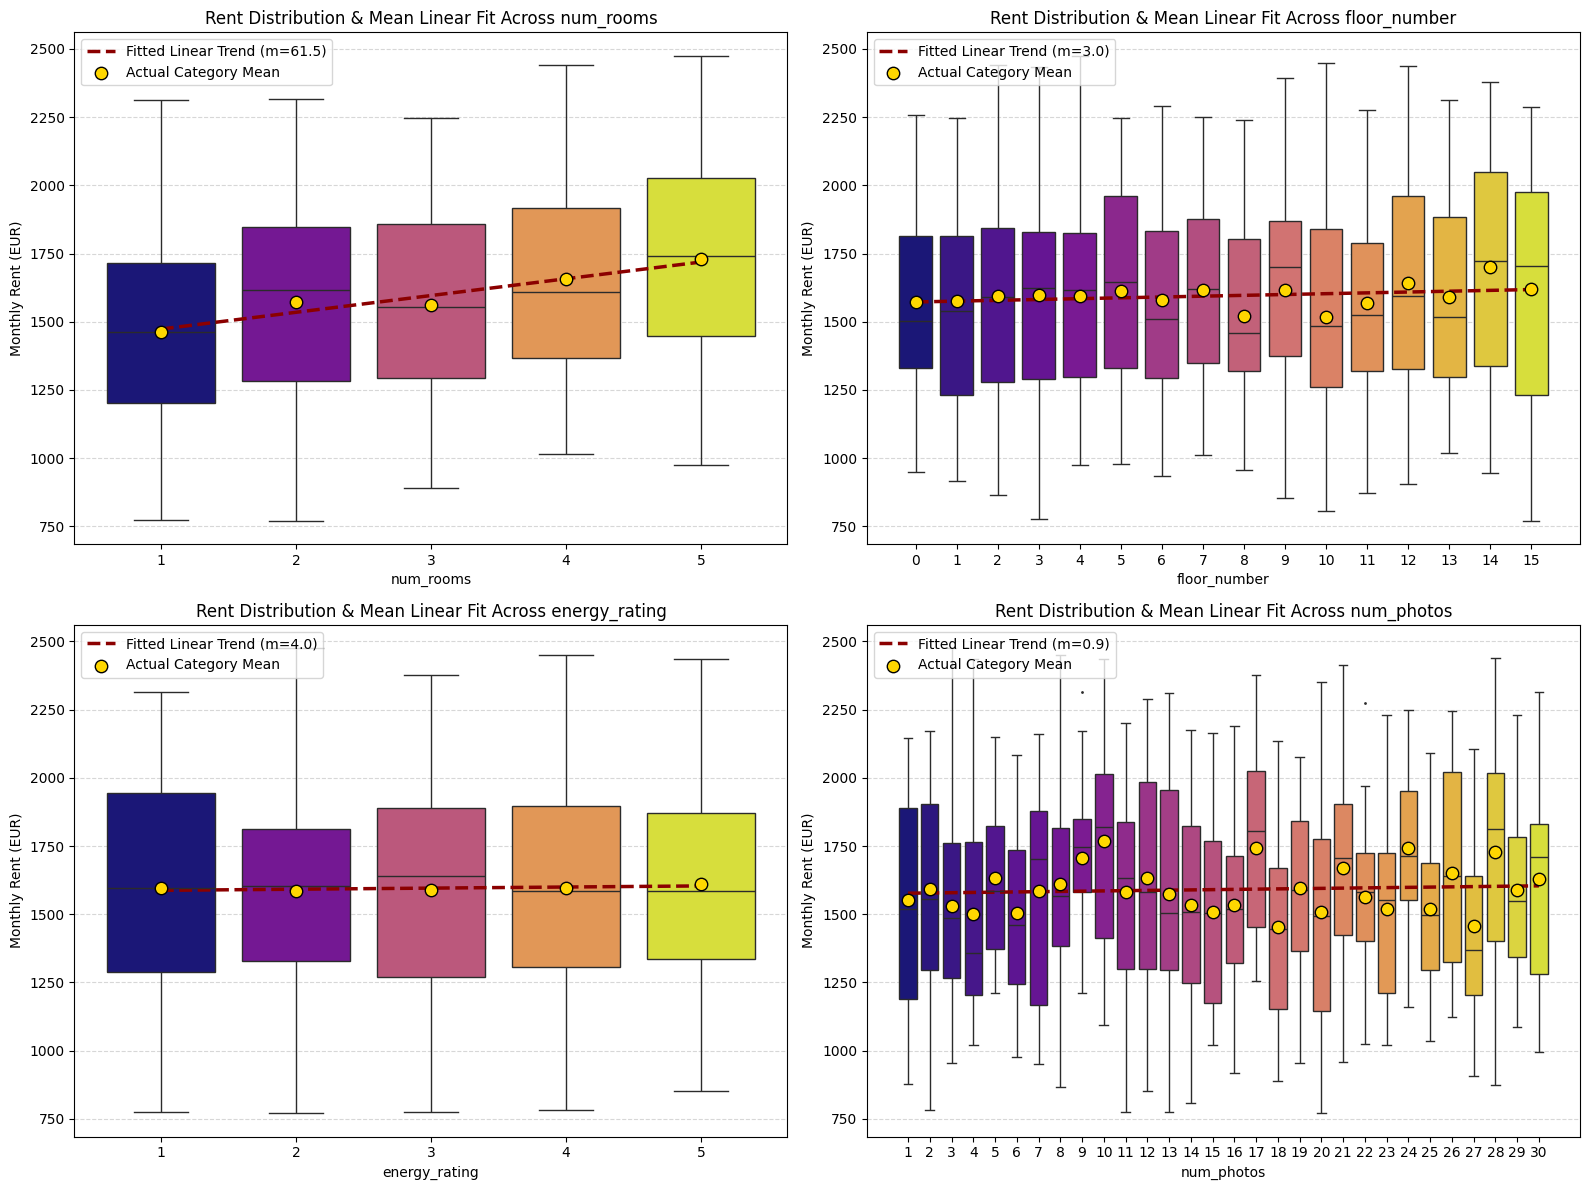

In [5]:
# 2. Calculate correlation specifically for these integer columns against rent
integer_corr = (
    df_train[DISCRETE + ["rent_eur_month"]]
    .corr(method="pearson")["rent_eur_month"]
    .drop("rent_eur_month")
    .sort_values(ascending=False)
)

# 3. Plot the Correlation Ranking
plt.figure(figsize=(8, 4))
sns.barplot(
    x=integer_corr.values, y=integer_corr.index, hue=integer_corr.index, palette="coolwarm_r", orient="h"
)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.title("Correlation Strength: Integer Features vs Rent")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Integer Features")
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

# 4. Generate Box Plots for key structural integer steps to inspect variance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(DISCRETE):
    # Calculate the mean rent for each discrete step and sort by index
    group_means = df_train.groupby(col)["rent_eur_month"].mean().sort_index()
    
    # Draw the baseline boxplot
    sns.boxplot(
        data=df_train,
        x=col,
        y="rent_eur_month",
        hue=col,
        ax=axes[idx],
        palette="plasma",
        legend=False,
        fliersize=1,  # Keep outlier dots tiny
    )
    
    # --- CALCULATE & FIT A LINEAR REGRESSION LINE ---
    x_indices = np.arange(len(group_means))
    y_means = group_means.values
    
    # Fit a 1st-degree polynomial (straight line)
    slope, intercept = np.polyfit(x_indices, y_means, 1)
    fitted_linear_y = slope * x_indices + intercept
    
    # Plot the true linear line of best fit
    axes[idx].plot(
        x_indices, 
        fitted_linear_y, 
        color="darkred",        
        linestyle="--",        
        linewidth=2.5,         
        label=f"Fitted Linear Trend (m={slope:.1f})"
    )
    
    # Plot the actual mean center points (Fixed zorder here 🥇)
    axes[idx].scatter(
        x_indices,
        y_means,
        color="gold",
        s=80,
        edgecolor="black",
        zorder=5,               # Fixed: changed zIndex to zorder
        label="Actual Category Mean"
    )
    
    # Configure titles, labels, and individual legends
    axes[idx].set_title(f"Rent Distribution & Mean Linear Fit Across {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Monthly Rent (EUR)")
    axes[idx].grid(axis="y", linestyle="--", alpha=0.5)
    axes[idx].legend(loc="upper left")

plt.tight_layout()
plt.show()

#### Interpretation

`num_rooms` stands out with a moderate positive correlation (**r ≈ 0.24**), reflecting the expected size premium. The remaining three features exhibit negligible correlations (**r < 0.05**), suggesting they have minimal influence on the predictions.

### 2.4. Correlation of Binary Features

--- Absolute Premium for has_elevator ---
Mean Rent without: €1596.46
Mean Rent with:    €1594.79
Net Price Increase: +€-1.67

--- Absolute Premium for has_parking ---
Mean Rent without: €1557.88
Mean Rent with:    €1666.60
Net Price Increase: +€108.72



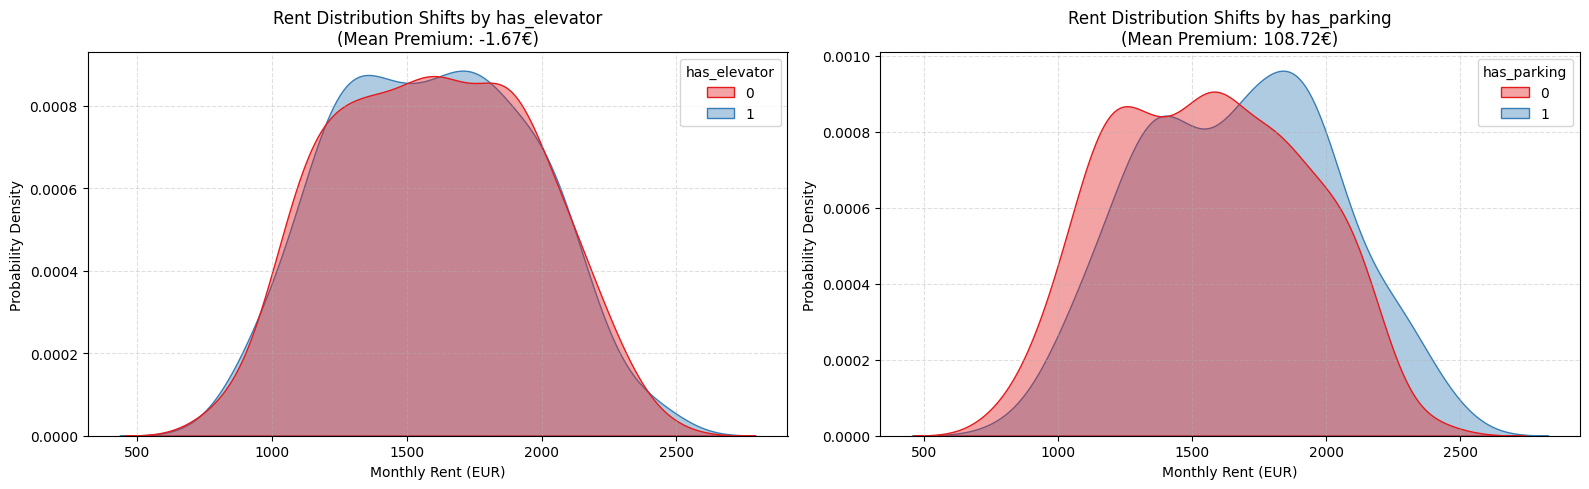

In [19]:
# 2. Render Overlapping Density Plots to inspect structural price premiums
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, col in enumerate(BINARY):
    # Calculate quantitative pricing means to find the true premium
    group_means = df_train.groupby(col)["rent_eur_month"].mean()
    
    # Premium = Mean Rent with amenity (1) minus Mean Rent without amenity (0)
    premium = group_means.loc[1] - group_means.loc[0]
    
    print(f"--- Absolute Premium for {col} ---")
    print(f"Mean Rent without: €{group_means.loc[0]:.2f}")
    print(f"Mean Rent with:    €{group_means.loc[1]:.2f}")
    print(f"Net Price Increase: +€{premium:.2f}\n")

    # Generate the KDE distribution plots
    sns.kdeplot(
        data=df_train,
        x="rent_eur_month",
        hue=col,
        fill=True,
        common_norm=False,
        palette="Set1",
        alpha=0.4,
        ax=axes[idx],
    )
    
    # Visual Polish
    axes[idx].set_title(
        f"Rent Distribution Shifts by {col}\n(Mean Premium: {premium:.2f}€)"
    )
    axes[idx].set_xlabel("Monthly Rent (EUR)")
    axes[idx].set_ylabel("Probability Density")
    axes[idx].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

`has_elevator` produces nearly identical density curves for both classes, indicating a negligible price bump. Conversely, `has_parking` induces a meaningful rightward distributional shift of approximately **+€87/month**. 

### 2.2 Surface Area against Rent

After examining all of the features, we can discern that the surface area is the most dominant predictor.

Let us inspect the relationship between rent and the surface.

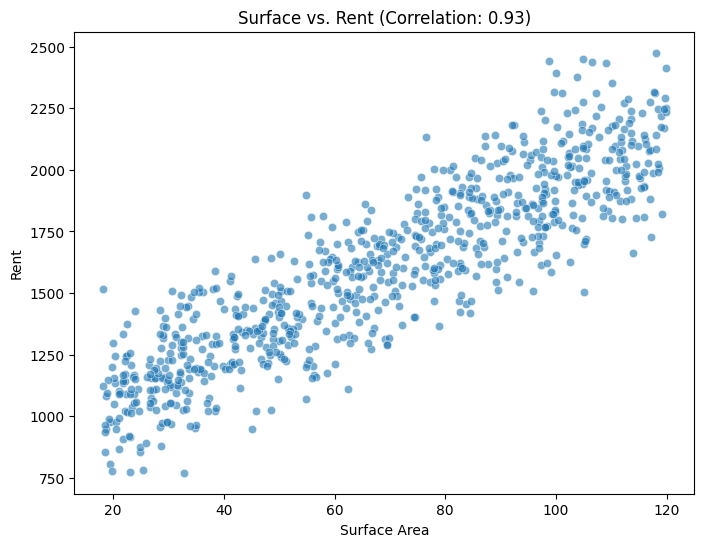

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="surface_m2", y="rent_eur_month", alpha=0.6)
plt.title("Surface vs. Rent (Correlation: 0.93)")
plt.xlabel("Surface Area")
plt.ylabel("Rent")
plt.show()

#### Interpretation

We can see an obvious linear relationship between rent and the surface area with no extreme outliers.

Thus, it suggests us to build a Linear Regression model as our evaluation baseline model.

## 3. Baseline Model 
We will fit a standard OLS Linear Regression purely on the surface area and evaluate it using $R^2$, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [8]:
baseline_model = LinearRegression()
baseline_model.fit(X_train[["surface_m2"]], Y_train)

Y_pred_train = baseline_model.predict(X_train[["surface_m2"]])
Y_pred_test = baseline_model.predict(X_test[["surface_m2"]])

mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)

print("--- Baseline Linear Regression Performance ---")
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train:.2f}")
print(f"Testing MSE:        {mse_test:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test):.2f}")

--- Baseline Linear Regression Performance ---
Training R-squared: 0.7944
Testing R-squared:  0.8093
----------------------------------------
Training MSE:       27049.33
Testing MSE:        27468.00
----------------------------------------
Training RMSE:      €164.47
Testing RMSE:       €165.73


#### Interpretation
We can already see that the model based on just the surface has already has a decent accuracy.

Let us try and observe if we can improve it furhter.

## 3.1. Residual Analysis

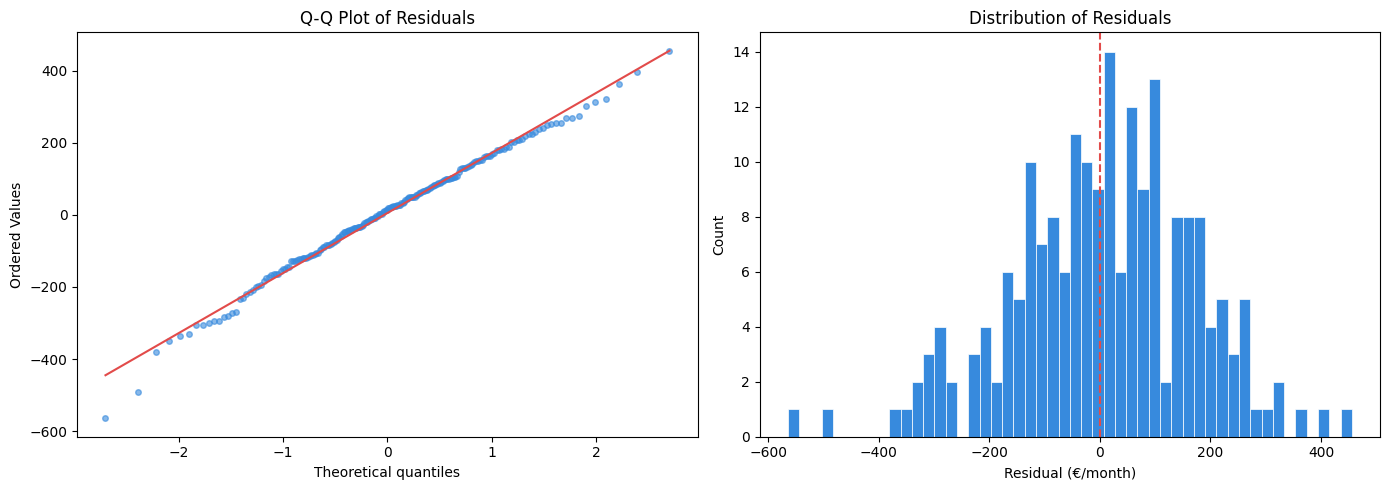

In [9]:
residuals = (Y_test - Y_pred_test).reset_index(drop=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Q-Q Plot of Residuals
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].get_lines()[0].set(
    color='#378ADD',
    markersize=4,
    alpha=0.6
)
axes[0].get_lines()[1].set(
    color='#E24B4A',
    linewidth=1.5
)
axes[0].set_title('Q-Q Plot of Residuals')

# 2. Distribution of Residuals (Histogram)
axes[1].hist(
    residuals,
    bins=50,
    color='#378ADD',
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (€/month)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

#### Interpretation

We can discern that the residuals follow a normal distribution well with heavy tails.



## 3.2 Linear Model on all Features
Given that every feature has some linear correlation with the rental prices, our next step is to apply the Linear Regression model on every feature.

In [10]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

Y_pred_train = linear_model.predict(X_train)
Y_pred_test = linear_model.predict(X_test)

mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)

print("--- Linear Regression Performance ---")
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train:.2f}")
print(f"Testing MSE:        {mse_test:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test):.2f}")

--- Linear Regression Performance ---
Training R-squared: 0.9262
Testing R-squared:  0.9389
----------------------------------------
Training MSE:       9707.05
Testing MSE:        8800.02
----------------------------------------
Training RMSE:      €98.52
Testing RMSE:       €93.81


### Interpretation
Our results display that this new model has an incredibly accuracy.


### 3.2.1 Residual Analysis

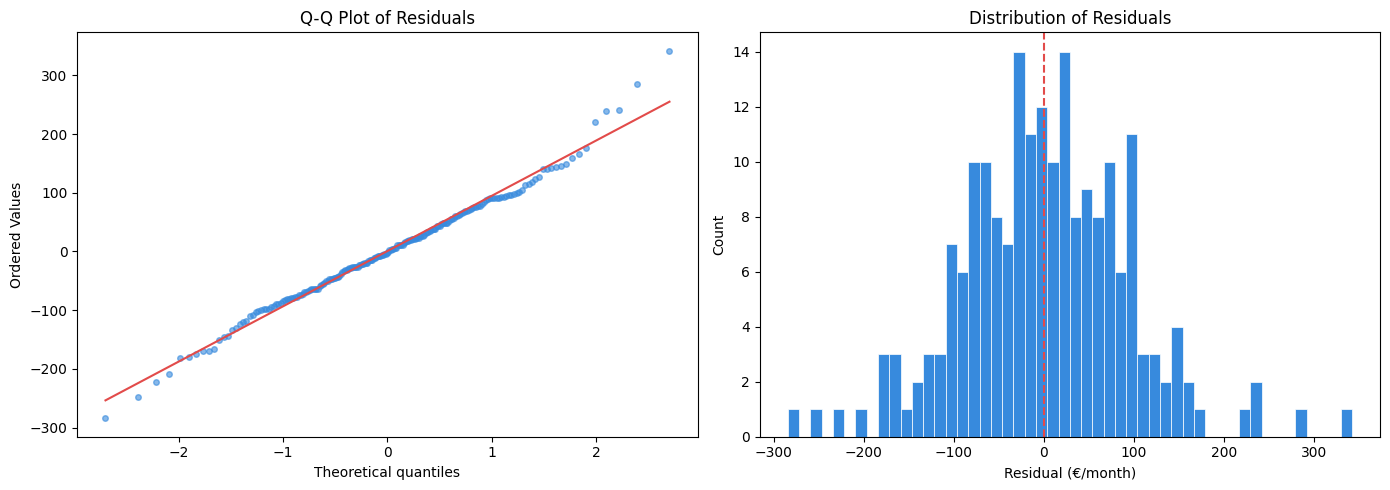

In [11]:
residuals = (Y_test - Y_pred_test).reset_index(drop=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Q-Q Plot of Residuals
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].get_lines()[0].set(
    color='#378ADD',
    markersize=4,
    alpha=0.6
)
axes[0].get_lines()[1].set(
    color='#E24B4A',
    linewidth=1.5
)
axes[0].set_title('Q-Q Plot of Residuals')

# 2. Distribution of Residuals (Histogram)
axes[1].hist(
    residuals,
    bins=50,
    color='#378ADD',
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (€/month)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

#### Interpretation

We can observe that the residuals follow the normal disitribution well between -1.5 and 1.5 quantiles, but has heavy tails at extreme ends.

Additionally, we can discern that the spread of the distribution is much smaller to the one of the baseline model.

## 4. Regularization
Even though we already achieved an astonishing accuracy by purely applying a LR model on all features, we want to find out whether every feature is truly beneficial for the model predictions. To check that, we will use regularization

### 4.1. Ridge Regression

In [12]:
# 2. Define the Preprocessor from scratch
# Continuous features get scaled. Discrete and Binary are treated as 
# categorical and converted into dummy variables via OneHotEncoder.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), CONTINUOUS),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), DISCRETE + BINARY),
    ]
)

# 3. Define a range of alpha values to test via Cross-Validation (5-Fold)
alphas_to_test = np.logspace(-2, 2, 250)
ridge_cv_regressor = RidgeCV(
    alphas=alphas_to_test, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

# 4. Assemble the final Ridge Pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", ridge_cv_regressor)
    ]
)

# 5. Fit the entire pipeline on your multi-feature training data
ridge_pipeline.fit(X_train, Y_train)

# 6. Extract the optimal alpha discovered by CV
best_alpha = ridge_pipeline.named_steps['regressor'].alpha_

# 7. Predict and Evaluate
Y_pred_train_ridge = ridge_pipeline.predict(X_train)
Y_pred_test_ridge = ridge_pipeline.predict(X_test)

mse_train_ridge = mean_squared_error(Y_train, Y_pred_train_ridge)
mse_test_ridge = mean_squared_error(Y_test, Y_pred_test_ridge)

print("--- Ridge Regression Performance ---")
print(f"Best Alpha (Regularization Strength): {best_alpha:.4f}")
print("-" * 40)
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train_ridge):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_ridge):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train_ridge:.2f}")
print(f"Testing MSE:        {mse_test_ridge:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train_ridge):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_ridge):.2f}")

--- Ridge Regression Performance ---
Best Alpha (Regularization Strength): 4.6416
----------------------------------------
Training R-squared: 0.9290
Testing R-squared:  0.9357
----------------------------------------
Training MSE:       9340.84
Testing MSE:        9255.59
----------------------------------------
Training RMSE:      €96.65
Testing RMSE:       €96.21


#### Interpretation

We can see that the Ridge Regression model improves the Train MSE, but the Test MSE becomes worse compared to our previous linear model. Therefore, based on these changes in the metrics, we can deduce that the Ridge model started overfitting.

This indicates that the dataset does not suffer from multicollinearity or severe overfitting in its raw linear form.

Next, we treat discrete as continuous as well.


In [13]:
# 2. Define the Preprocessor from scratch
# Continuous features get scaled. Discrete and Binary are treated as 
# categorical and converted into dummy variables via OneHotEncoder.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), CONTINUOUS + DISCRETE), # Scaled linearly
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), BINARY), # Exploded
    ]
)

# 3. Define a range of alpha values to test via Cross-Validation (5-Fold)
alphas_to_test = np.logspace(-2, 2, 250)
ridge_cv_regressor = RidgeCV(
    alphas=alphas_to_test, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

# 4. Assemble the final Ridge Pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", ridge_cv_regressor)
    ]
)

# 5. Fit the entire pipeline on your multi-feature training data
ridge_pipeline.fit(X_train, Y_train)

# 6. Extract the optimal alpha discovered by CV
best_alpha = ridge_pipeline.named_steps['regressor'].alpha_

# 7. Predict and Evaluate
Y_pred_train_ridge = ridge_pipeline.predict(X_train)
Y_pred_test_ridge = ridge_pipeline.predict(X_test)

mse_train_ridge = mean_squared_error(Y_train, Y_pred_train_ridge)
mse_test_ridge = mean_squared_error(Y_test, Y_pred_test_ridge)

print("--- Ridge Regression Performance ---")
print(f"Best Alpha (Regularization Strength): {best_alpha:.4f}")
print("-" * 40)
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train_ridge):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_ridge):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train_ridge:.2f}")
print(f"Testing MSE:        {mse_test_ridge:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train_ridge):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_ridge):.2f}")

--- Ridge Regression Performance ---
Best Alpha (Regularization Strength): 3.0900
----------------------------------------
Training R-squared: 0.9262
Testing R-squared:  0.9387
----------------------------------------
Training MSE:       9709.31
Testing MSE:        8823.09
----------------------------------------
Training RMSE:      €98.54
Testing RMSE:       €93.93


Every feature linear.

In [14]:
# 2. Define the Preprocessor from scratch
# Continuous features get scaled. Discrete and Binary are treated as 
# categorical and converted into dummy variables via OneHotEncoder.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), CONTINUOUS + DISCRETE + BINARY), # Scaled linearly
    ]
)

# 3. Define a range of alpha values to test via Cross-Validation (5-Fold)
alphas_to_test = np.logspace(-2, 2, 250)
ridge_cv_regressor = RidgeCV(
    alphas=alphas_to_test, 
    cv=5, 
    scoring='neg_mean_squared_error'
)

# 4. Assemble the final Ridge Pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", ridge_cv_regressor)
    ]
)

# 5. Fit the entire pipeline on your multi-feature training data
ridge_pipeline.fit(X_train, Y_train)

# 6. Extract the optimal alpha discovered by CV
best_alpha = ridge_pipeline.named_steps['regressor'].alpha_

# 7. Predict and Evaluate
Y_pred_train_ridge = ridge_pipeline.predict(X_train)
Y_pred_test_ridge = ridge_pipeline.predict(X_test)

mse_train_ridge = mean_squared_error(Y_train, Y_pred_train_ridge)
mse_test_ridge = mean_squared_error(Y_test, Y_pred_test_ridge)

print("--- Ridge Regression Performance ---")
print(f"Best Alpha (Regularization Strength): {best_alpha:.4f}")
print("-" * 40)
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train_ridge):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_ridge):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train_ridge:.2f}")
print(f"Testing MSE:        {mse_test_ridge:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train_ridge):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_ridge):.2f}")

--- Ridge Regression Performance ---
Best Alpha (Regularization Strength): 2.3851
----------------------------------------
Training R-squared: 0.9262
Testing R-squared:  0.9388
----------------------------------------
Training MSE:       9708.14
Testing MSE:        8813.31
----------------------------------------
Training RMSE:      €98.53
Testing RMSE:       €93.88


### 4.2. Lasso Regression


In [15]:
all_features = CONTINUOUS + DISCRETE + BINARY

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), all_features)
    ]
)

# 2. Setup Lasso with a range of alphas and 5-Fold Cross-Validation
# Note: Lasso can be sensitive to the alpha scale, so we check a wide exponential range
alphas_to_test = np.logspace(-10, 10, 1000)
lasso_cv_regressor = LassoCV(
    alphas=alphas_to_test, 
    cv=5, 
    max_iter=10000, # Increased iterations to ensure the math fully converges
    random_state=42
)

# 3. Assemble and fit the Lasso Pipeline
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor), 
        ("regressor", lasso_cv_regressor)
    ]
)
lasso_pipeline.fit(X_train, Y_train)

# 4. Extract performance metrics
best_alpha_lasso = lasso_pipeline.named_steps['regressor'].alpha_
Y_pred_test_lasso = lasso_pipeline.predict(X_test)
mse_test_lasso = mean_squared_error(Y_test, Y_pred_test_lasso)

print("--- Lasso Regression Performance ---")
print(f"Best Alpha (L1 Penalty Strength): {best_alpha_lasso:.4f}")
print("-" * 40)
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_lasso):.4f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_lasso):.2f}")

--- Lasso Regression Performance ---
Best Alpha (L1 Penalty Strength): 0.2948
----------------------------------------
Testing R-squared:  0.9388
Testing RMSE:       €93.90


In [16]:
lasso_coefs = lasso_pipeline.named_steps['regressor'].coef_

print("\n--- Lasso Feature Coefficients ---")
for feature, coef in zip(all_features, lasso_coefs):
    print(f"{feature:<30} : {coef:.4f}")


--- Lasso Feature Coefficients ---
surface_m2                     : 321.3026
building_age_years             : -10.2940
distance_metro_km              : -47.9818
district_prestige_score        : 80.5902
construction_quality_score     : 19.7998
distance_supermarket_m         : -4.2864
num_rooms                      : 77.7188
floor_number                   : 6.1217
energy_rating                  : 24.4662
num_photos                     : 14.5329
has_elevator                   : 6.8139
has_parking                    : 41.2571


### Interpretation

As none of the coefficients are zero, we can conclude that we need every feature for it to work.

## 5. Random Forests

We want an alternative approach and check whether the dataset truly has linear properties. Since we have features that have different data types, we can try random forests.

In [17]:
# 1. Setup your uniform feature pipeline
all_features = CONTINUOUS + DISCRETE + BINARY
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), all_features)]
)

# 2. Initialize the base Random Forest model
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 3. Create the pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", rf_base)
])

# 4. Define the Parameter Grid
# Note: In a pipeline, you must prefix hyperparameter names with "regressor__"
param_grid = {
    'regressor__max_depth': [5, 9, 10, 11, 12, 13, 14],          # Controls ultimate depth
    'regressor__min_samples_split': [2, 3, 4, 5],          # Prevents splitting on tiny noise
    'regressor__max_features': ['sqrt', 0.6, 0.65, 0.7, 0.75, 0.8]        # Internal feature selection mechanics
}

# 5. Set up the Grid Search with 5-Fold Cross Validation
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 6. Fit the Grid Search
rf_grid_search.fit(X_train, Y_train)

# 7. Extract the best parameters and evaluate
best_params = rf_grid_search.best_params_
best_rf_model = rf_grid_search.best_estimator_

Y_pred_test_rf = best_rf_model.predict(X_test)
mse_test_rf = mean_squared_error(Y_test, Y_pred_test_rf)

print("--- Optimized Random Forest Performance ---")
print("Best Hyperparameters Found:")
for param, val in best_params.items():
    print(f"  {param.split('__')[1]}: {val}")
print("-" * 40)
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_rf):.4f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_rf):.2f}")

--- Optimized Random Forest Performance ---
Best Hyperparameters Found:
  max_depth: 11
  max_features: 0.75
  min_samples_split: 2
----------------------------------------
Testing R-squared:  0.8939
Testing RMSE:       €123.61


In [18]:
rf_raw_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. Define the Parameter Grid
# Because we aren't using a pipeline, we don't need the "regressor__" prefix anymore!
param_grid = {
    'max_depth': [10, 15, 20, None],          # Finding the ultimate depth limit
    'min_samples_split': [2, 5, 10],          # Stopping splits on minor noisy data
    'max_features': ['sqrt', 0.7, 0.8]        # Internal feature selection mechanics
}

# 3. Set up the Grid Search with 5-Fold Cross Validation
rf_raw_grid = GridSearchCV(
    estimator=rf_raw_base,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 4. Fit directly on your raw training data
rf_raw_grid.fit(X_train, Y_train)

# 5. Extract the absolute best model and parameters
best_raw_params = rf_raw_grid.best_params_
best_raw_rf_model = rf_raw_grid.best_estimator_

# 6. Predict and Evaluate on Test Set
Y_pred_test_raw_rf = best_raw_rf_model.predict(X_test)
mse_test_raw_rf = mean_squared_error(Y_test, Y_pred_test_raw_rf)

print("--- Optimized Raw Random Forest Performance ---")
print("Best Hyperparameters Found:")
for param, val in best_raw_params.items():
    print(f"  {param}: {val}")
print("-" * 40)
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test_raw_rf):.4f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test_raw_rf):.2f}")

--- Optimized Raw Random Forest Performance ---
Best Hyperparameters Found:
  max_depth: 15
  max_features: 0.8
  min_samples_split: 5
----------------------------------------
Testing R-squared:  0.8920
Testing RMSE:       €124.70


#### Interpretation

We can see that test MSE of random forest is noticably lower compared to the linear model, proving our conjecture of the dataset having linear properties. Hence, there is no need to do boosting as it still would not beat a linear model purely because of the properties of the dataset.